In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import imdb
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer#文本特征抽取包 
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

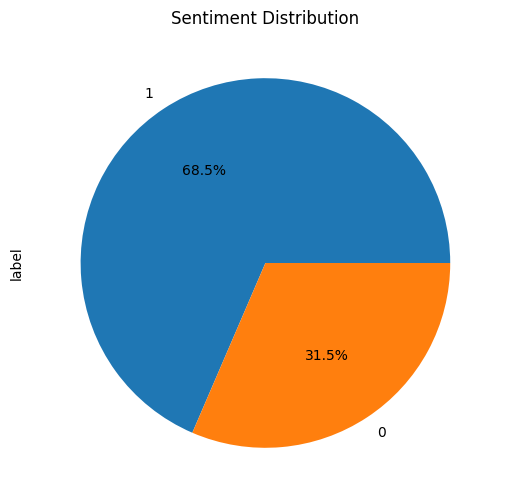

In [4]:
# 读取数据
data = pd.read_csv("C:\\Users\\yuan\\Desktop\\lecture7\\酒店文本评价.csv", encoding="gbk")

# 输出数据分布的饼图
data['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Sentiment Distribution')
plt.show()

In [6]:
# 划分输入变量和输出变量
X = data['review']
y = data['label']

In [10]:
# 使用TfidfVectorizer将文本转化为向量
vec = TfidfVectorizer(max_features=2000, min_df=0.01, max_df=0.99)  # 调整 min_df 和 max_df
X = vec.fit_transform(X.values.astype('U')).toarray()

In [11]:
# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=9063)

In [12]:
# 创建随机森林分类器
rf = RandomForestClassifier(n_estimators=250, random_state=9063)

In [13]:
# 训练模型
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=250, random_state=9063)

In [14]:
# 预测测试集
y_pred_forest = rf.predict(X_test)

In [15]:
# 计算准确率
accuracy_forest = accuracy_score(y_test, y_pred_forest)
print("Random Forest Accuracy:", accuracy_forest)
print(classification_report(y_test, y_pred_forest))
conf_mat_forest = confusion_matrix(y_test, y_pred_forest)
print("Random Forest Confusion Matrix:\n", conf_mat_forest)

Random Forest Accuracy: 0.6824034334763949
              precision    recall  f1-score   support

           0       0.46      0.02      0.03       738
           1       0.69      0.99      0.81      1592

    accuracy                           0.68      2330
   macro avg       0.57      0.50      0.42      2330
weighted avg       0.62      0.68      0.56      2330

Random Forest Confusion Matrix:
 [[  13  725]
 [  15 1577]]


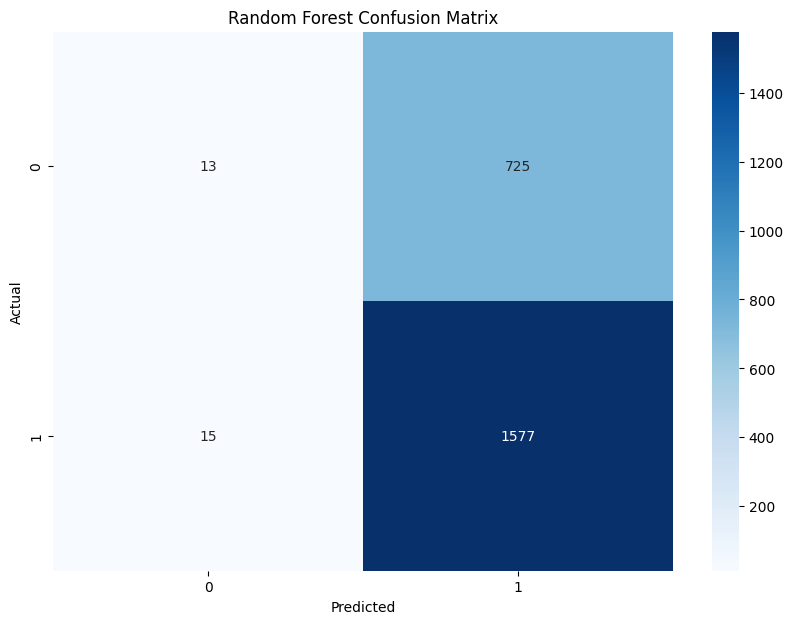

In [16]:
# 绘制随机森林混淆矩阵
plt.figure(figsize=(10, 7))
sns.heatmap(conf_mat_forest, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
# 创建决策树分类器
tree_clf = DecisionTreeClassifier(random_state=9063)

In [18]:
# 训练模型
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=9063)

In [19]:
# 预测测试集
y_pred_tree = tree_clf.predict(X_test)

In [20]:
# 计算准确率
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", accuracy_tree)
print(classification_report(y_test, y_pred_tree))
conf_mat_tree = confusion_matrix(y_test, y_pred_tree)
print("Decision Tree Confusion Matrix:\n", conf_mat_tree)

Decision Tree Accuracy: 0.6824034334763949
              precision    recall  f1-score   support

           0       0.46      0.02      0.03       738
           1       0.69      0.99      0.81      1592

    accuracy                           0.68      2330
   macro avg       0.57      0.50      0.42      2330
weighted avg       0.62      0.68      0.56      2330

Decision Tree Confusion Matrix:
 [[  13  725]
 [  15 1577]]


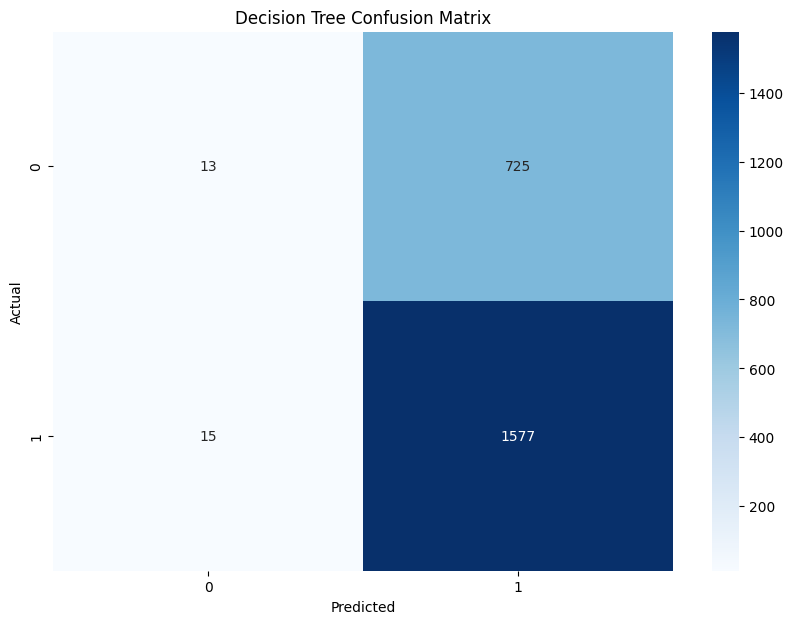

In [21]:
# 绘制决策树混淆矩阵
plt.figure(figsize=(10, 7))
sns.heatmap(conf_mat_tree, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()